In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
# Tentukan path ke file True.csv dan Fake.csv di Google Drive Anda.
# Sesuaikan path ini jika file-file Anda berada di lokasi yang berbeda di Drive.
true_csv_path = 'dataset/True.csv'
fake_csv_path = 'dataset/Fake.csv'


In [7]:
def load_and_preprocess_data(true_path, fake_path):
    print("1. Memulai data ingestion...")
    true_df = pd.read_csv(true_path)
    fake_df = pd.read_csv(fake_path)

    true_df['label'] = 1
    fake_df['label'] = 0

    # Menggabungkan kedua dataset
    df = pd.concat([true_df, fake_df], axis=0).reset_index(drop=True)

    df = df.drop(['date'], axis=1)
    df = df.drop(['subject'], axis=1)

    return df

In [8]:
# Panggil fungsi untuk memuat dan memproses data
data = load_and_preprocess_data(true_csv_path, fake_csv_path)

# Tampilkan beberapa baris pertama dari data yang sudah diproses
print(data.head())

1. Memulai data ingestion...
                                               title  \
0  As U.S. budget fight looms, Republicans flip t...   
1  U.S. military to accept transgender recruits o...   
2  Senior U.S. Republican senator: 'Let Mr. Muell...   
3  FBI Russia probe helped by Australian diplomat...   
4  Trump wants Postal Service to charge 'much mor...   

                                                text  label  
0  WASHINGTON (Reuters) - The head of a conservat...      1  
1  WASHINGTON (Reuters) - Transgender people will...      1  
2  WASHINGTON (Reuters) - The special counsel inv...      1  
3  WASHINGTON (Reuters) - Trump campaign adviser ...      1  
4  SEATTLE/WASHINGTON (Reuters) - President Donal...      1  


In [ ]:
# Simpan DataFrame 'data' yang sudah digabung ke file CSV baru
data.to_csv('dataset/data.csv', index=False)
print("Data berhasil disimpan ke 'combined_data.csv'")

Data berhasil disimpan ke 'combined_data.csv'


In [10]:
import nltk
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [11]:
from numpy import nan
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def clean_text(text):
    if not isinstance(text, str):
        return nan

    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = text.split()

    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    text = " ".join(tokens)

    if text == "":
        return nan

    return text

data["title"] = data["title"].apply(clean_text)
data["text"] = data["text"].apply(clean_text)

data = data.dropna(subset=["title"]).reset_index(drop=True)
data = data.dropna(subset=["text"]).reset_index(drop=True)

data["string"] = data['title'] + ' ' + data['text']
data = data.drop(columns=['title', 'text'])

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44266 entries, 0 to 44265
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   44266 non-null  int64 
 1   string  44266 non-null  object
dtypes: int64(1), object(1)
memory usage: 691.8+ KB


In [12]:
from sklearn.utils import resample
from collections import Counter
import pandas as pd
import re

def smooth_dataset(df):

    def clean_repeated(text):
        # Ensure text is a string before applying regex
        if not isinstance(text, str):
            return text
        text = re.sub(r"(.)\\1{2,}", r"\\1\\1", text)
        return text

    # Apply clean_repeated to the 'content' column instead of 'title'
    df["string"] = df["string"].apply(clean_repeated)

    # Re-evaluate all words from the 'content' column
    all_words = " ".join(df["string"].dropna().tolist()).split()

    counter = Counter(all_words)

    rare_words = {
        word for word, freq in counter.items()
        if freq < 3
    }

    def remove_rare_words(text):
        # Ensure text is a string before processing
        if not isinstance(text, str):
            return text
        words = text.split()

        filtered_words = [
            word for word in words
            if word not in rare_words
        ]
        return " ".join(filtered_words)

    # Apply remove_rare_words to the 'content' column
    df["string"] = df["string"].apply(remove_rare_words)
    df["string"] = df["string"].str.strip()

    # Remove rows where 'content' becomes empty after processing
    df = df[df["string"] != ""]

    df = df.reset_index(drop=True)

    return df

# Pass the 'data' DataFrame (your main processed data) to the smooth_dataset function
data = smooth_dataset(data.copy()) # Using .copy() to avoid modifying the original 'data' DataFrame directly
print("Dataset after smoothing (first 5 rows):")
print(data.head())
print("\nInfo on balanced dataset:")
data.info()

Dataset after smoothing (first 5 rows):
   label                                             string
0      1  us budget fight looms republicans flip fiscal ...
1      1  us military accept transgender recruits monday...
2      1  senior us republican senator let mr mueller jo...
3      1  fbi russia probe helped australian diplomat ti...
4      1  trump wants postal service charge much amazon ...

Info on balanced dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44263 entries, 0 to 44262
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   44263 non-null  int64 
 1   string  44263 non-null  object
dtypes: int64(1), object(1)
memory usage: 691.7+ KB


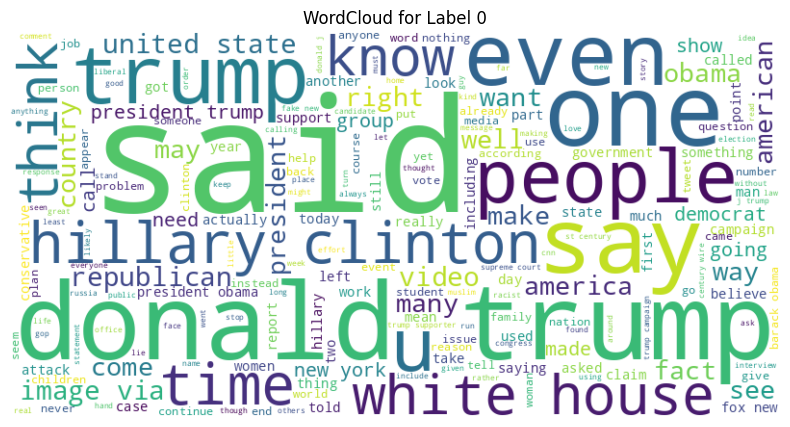

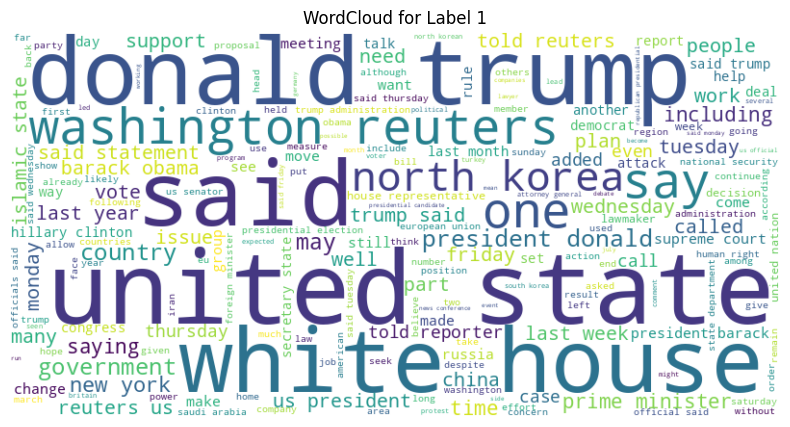

In [13]:
df = data.copy()

from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Get unique labels
labels = sorted(df["label"].unique())

# Create wordcloud for each label
for label in labels:

    # Combine all text from the same label
    text = " ".join(
        df[df["label"] == label]["string"]
    )

    # Generate wordcloud
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white"
    ).generate(text)

    # Plot
    plt.figure(figsize=(10, 5))

    plt.imshow(wordcloud, interpolation="bilinear")

    plt.axis("off")

    plt.title(f"WordCloud for Label {label}")

    plt.show()

In [14]:
# Memisahkan fitur (X) dan label (y)
X = data['string']
y = data['label']

# Membagi data menjadi set pelatihan dan pengujian
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (35410,)
Shape of X_test: (8853,)
Shape of y_train: (35410,)
Shape of y_test: (8853,)


In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMClassifier

def train_lightgbm_tfidf(X_train, X_test, y_train, y_test):

    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer()),
        ("lgbm", LGBMClassifier(importance_type='gain', verbosity=-1))
    ])

    # Refined hyperparameter grid to balance depth and memory
    params = {
        # TF-IDF Tuning
        "tfidf__max_df": [0.7, 0.8, 0.9],
        "tfidf__min_df": [2, 5],
        "tfidf__ngram_range": [(1, 1), (1, 2)],
        "tfidf__max_features": [10000, 20000, 30000], # Slightly reduced to save RAM
        "tfidf__sublinear_tf": [True],

        # LightGBM Tuning
        "lgbm__boosting_type": ['gbdt'],
        "lgbm__n_estimators": [500, 1000],
        "lgbm__learning_rate": [0.01, 0.05, 0.1],
        "lgbm__num_leaves": [31, 63, 127],
        "lgbm__max_depth": [-1, 20],
        "lgbm__min_child_samples": [20, 50],
        "lgbm__subsample": [0.7, 0.8, 1.0],
        "lgbm__colsample_bytree": [0.7, 0.8, 1.0],
        "lgbm__reg_alpha": [0, 0.1, 1],
        "lgbm__reg_lambda": [0, 0.1, 1]
    }

    # Changed n_jobs to 1 to prevent Out-of-Memory (SIGKILL) errors
    model = RandomizedSearchCV(
        pipeline,
        params,
        n_iter=15,
        cv=3,
        scoring="accuracy",
        n_jobs=1,  # Serial processing to save memory
        verbose=2,
        random_state=42
    )

    print("Starting search... (This may take a while as it processes sequentially to save RAM)")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print("Best Hyperparameters:", model.best_params_)
    print("Test Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

    return model

model_tfidf_lgbm = train_lightgbm_tfidf(X_train, X_test, y_train, y_test)

Starting search... (This may take a while as it processes sequentially to save RAM)
Fitting 3 folds for each of 15 candidates, totalling 45 fits


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END lgbm__boosting_type=gbdt, lgbm__colsample_bytree=0.8, lgbm__learning_rate=0.1, lgbm__max_depth=-1, lgbm__min_child_samples=20, lgbm__n_estimators=1000, lgbm__num_leaves=127, lgbm__reg_alpha=0.1, lgbm__reg_lambda=0.1, lgbm__subsample=0.7, tfidf__max_df=0.9, tfidf__max_features=10000, tfidf__min_df=5, tfidf__ngram_range=(1, 1), tfidf__sublinear_tf=True; total time= 1.3min


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END lgbm__boosting_type=gbdt, lgbm__colsample_bytree=0.8, lgbm__learning_rate=0.1, lgbm__max_depth=-1, lgbm__min_child_samples=20, lgbm__n_estimators=1000, lgbm__num_leaves=127, lgbm__reg_alpha=0.1, lgbm__reg_lambda=0.1, lgbm__subsample=0.7, tfidf__max_df=0.9, tfidf__max_features=10000, tfidf__min_df=5, tfidf__ngram_range=(1, 1), tfidf__sublinear_tf=True; total time= 1.2min


...

[CV] END lgbm__boosting_type=gbdt, lgbm__colsample_bytree=1.0, lgbm__learning_rate=0.1, lgbm__max_depth=-1, lgbm__min_child_samples=20, lgbm__n_estimators=1000, lgbm__num_leaves=63, lgbm__reg_alpha=1, lgbm__reg_lambda=0.1, lgbm__subsample=0.8, tfidf__max_df=0.9, tfidf__max_features=20000, tfidf__min_df=5, tfidf__ngram_range=(1, 2), tfidf__sublinear_tf=True; total time= 1.8min


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END lgbm__boosting_type=gbdt, lgbm__colsample_bytree=1.0, lgbm__learning_rate=0.1, lgbm__max_depth=-1, lgbm__min_child_samples=20, lgbm__n_estimators=1000, lgbm__num_leaves=63, lgbm__reg_alpha=1, lgbm__reg_lambda=0.1, lgbm__subsample=0.8, tfidf__max_df=0.9, tfidf__max_features=20000, tfidf__min_df=5, tfidf__ngram_range=(1, 2), tfidf__sublinear_tf=True; total time= 1.7min


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Best Hyperparameters: {'tfidf__sublinear_tf': True, 'tfidf__ngram_range': (1, 2), 'tfidf__min_df': 2, 'tfidf__max_features': 30000, 'tfidf__max_df': 0.9, 'lgbm__subsample': 0.8, 'lgbm__reg_lambda': 1, 'lgbm__reg_alpha': 0, 'lgbm__num_leaves': 31, 'lgbm__n_estimators': 1000, 'lgbm__min_child_samples': 50, 'lgbm__max_depth': 20, 'lgbm__learning_rate': 0.1, 'lgbm__colsample_bytree': 0.8, 'lgbm__boosting_type': 'gbdt'}
Test Accuracy: 0.998192703038518
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4573
           1       1.00      1.00      1.00      4280

    accuracy                           1.00      8853
   macro avg       1.00      1.00      1.00      8853
weighted avg       1.00      1.00      1.00      8853



In [ ]:
import joblib

# Save the trained model
joblib.dump(model_tfidf_lgbm, 'model.pkl')

print("Model saved as 'model.pkl'")

Model saved as 'model.pkl'
